# LSTM Prediction Pipeline

This notebook aggregates the full pipeline by importing the project scripts:

- `indicator.py`: technical indicators and Pearson IC feature selection
- `tensor_transform.py`: 3-D LSTM tensor construction
- `LSTM.py`: LSTM model training and prediction
- `benchmark.py`: Nasdaq, S&P 500, and SOX benchmark run
- `plot_results.py`: Matplotlib plots for tensor and daily price prediction

In [1]:
from pathlib import Path
import importlib
import json

import numpy as np
import pandas as pd
from IPython.display import Image, display

import benchmark
import indicator
import tensor_transform
import plot_results

# Jupyter keeps imported modules cached. Reload project scripts after edits.
importlib.reload(benchmark)
importlib.reload(indicator)
importlib.reload(tensor_transform)
importlib.reload(plot_results)

from benchmark import INDEX_TICKERS, run_benchmark
from indicator import add_technical_indicators, select_features_by_ic
from tensor_transform import build_lstm_tensors
from plot_results import plot_tensor_surface, plot_price_predictions

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## Configuration

In [2]:
START = "2010-01-01"
END = "2026-06-01"
TRAIN_END = "2025-12-31"
TEST_START = "2026-01-01"
TEST_END = "2026-05-31"

LOOKBACK = 30
# 21 trading days is approximately one month. The input window still updates every trading day.
HORIZON = 21
TOP_K = 16
EPOCHS = 80

OUTPUT_DIR = Path(f"outputs_h{HORIZON}")
PLOTS_DIR = Path(f"plots_h{HORIZON}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Set this to False if you only want to reload existing CSV outputs and regenerate plots.
RUN_TRAINING = True


## Train LSTM And Build Benchmark Outputs

The training target is horizon log return. With `HORIZON = 21`, each trading day uses the latest lookback window to predict the close about one month later.

In [3]:
if RUN_TRAINING:
    results = []
    for index_name, ticker in INDEX_TICKERS.items():
        print(f"Running {index_name} ({ticker})...")
        result = run_benchmark(
            name=index_name,
            ticker=ticker,
            start=START,
            end=END,
            train_end=TRAIN_END,
            test_start=TEST_START,
            test_end=TEST_END,
            lookback=LOOKBACK,
            horizon=HORIZON,
            top_k=TOP_K,
            epochs=EPOCHS,
            output_dir=OUTPUT_DIR,
        )
        results.append(result)
        print(
            f"{index_name}: RMSE={result['rmse']:.2f}, MAE={result['mae']:.2f}, "
            f"MAPE={result['mape_pct']:.2f}%, Direction={result['direction_accuracy_pct']:.2f}%"
        )

    summary = pd.DataFrame(results)
    summary.to_csv(OUTPUT_DIR / "benchmark_summary.csv", index=False)
    (OUTPUT_DIR / "benchmark_summary.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
else:
    print("Skipped training. Loading existing benchmark outputs.")

Running Nasdaq (^IXIC)...
Nasdaq: RMSE=1642.17, MAE=1232.87, MAPE=5.04%, Direction=52.94%
Running SP500 (^GSPC)...
SP500: RMSE=300.62, MAE=246.84, MAPE=3.55%, Direction=53.92%
Running SOX (^SOX)...
SOX: RMSE=1873.27, MAE=1443.06, MAPE=14.71%, Direction=23.53%


## Benchmark Summary

In [4]:
summary = pd.read_csv(OUTPUT_DIR / "benchmark_summary.csv")
metric_cols = [
    "index", "ticker", "samples", "train_samples", "rmse", "mae", "mape_pct",
    "naive_rmse", "naive_mae", "rmse_vs_naive_pct", "mae_vs_naive_pct", "direction_accuracy_pct",
]
summary[metric_cols]

,index,ticker,samples,train_samples,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct
0,Nasdaq,^IXIC,102,3915,1642.173584,1232.871094,5.041891,1637.298584,1208.832153,-0.297747,-1.988609,52.941176
1,SP500,^GSPC,102,3915,300.625000,246.841476,3.549291,332.460724,252.797470,9.575785,2.356034,53.921569
2,SOX,^SOX,102,3915,1873.274658,1443.063477,14.705391,1488.667480,1114.594482,-25.835667,-29.469821,23.529412


## Inspect Feature IC Ranking

In [5]:
feature_ic = {
    index_name: pd.read_csv(OUTPUT_DIR / f"{index_name}_feature_ic.csv").head(TOP_K)
    for index_name in summary["index"]
}
feature_ic["Nasdaq"]

,feature,ic,abs_ic
0,High,0.994973,0.994973
1,Low,0.994897,0.994897
2,Open,0.994866,0.994866
3,MA_5,0.994738,0.994738
4,EMA_12,0.994469,0.994469
5,MA_10,0.994385,0.994385
6,EMA_26,0.993732,0.993732
7,MA_20,0.993606,0.993606
8,MA_60,0.990871,0.990871
9,Volume,0.884268,0.884268


## Build One Tensor Manually From Imported Scripts

This cell demonstrates the imported `indicator.py` and `tensor_transform.py` path explicitly.

In [6]:
example_index = "Nasdaq"
raw = pd.read_csv(OUTPUT_DIR / f"{example_index}_raw.csv", index_col=0, parse_dates=True)
features_df = add_technical_indicators(raw)
selected_features = pd.read_csv(OUTPUT_DIR / f"{example_index}_feature_ic.csv")["feature"].head(TOP_K).tolist()

tensor_data = build_lstm_tensors(
    features_df,
    feature_columns=selected_features,
    lookback=LOOKBACK,
    horizon=HORIZON,
    train_end=TRAIN_END,
    test_start=TEST_START,
    test_end=TEST_END,
    target_mode="log_return",
)

print("X_train:", tensor_data.X_train.shape)
print("y_train:", tensor_data.y_train.shape)
print("X_test:", tensor_data.X_test.shape)
print("y_test:", tensor_data.y_test.shape)
print("features:", tensor_data.feature_columns)

X_train: (3915, 30, 16)
y_train: (3915,)
X_test: (102, 30, 16)
y_test: (102,)
features: ['High', 'Low', 'Open', 'MA_5', 'EMA_12', 'MA_10', 'EMA_26', 'MA_20', 'MA_60', 'Volume', 'MACD_signal', 'MACD', 'Volatility_10', 'HL_range_pct', 'Close_to_MA_60', 'Close_to_EMA_26']


## Generate Matplotlib Plots

In [7]:
for index_name in summary["index"]:
    plot_tensor_surface(
        index_name=index_name,
        raw_path=OUTPUT_DIR / f"{index_name}_raw.csv",
        feature_ic_path=OUTPUT_DIR / f"{index_name}_feature_ic.csv",
        output_path=PLOTS_DIR / f"{index_name}_tensor_3d.png",
        lookback=LOOKBACK,
        horizon=HORIZON,
        top_k=TOP_K,
        train_end=TRAIN_END,
        test_start=TEST_START,
        test_end=TEST_END,
    )
    plot_price_predictions(
        index_name=index_name,
        prediction_path=OUTPUT_DIR / f"{index_name}_predictions.csv",
        output_path=PLOTS_DIR / f"{index_name}_price_prediction.png",
    )

sorted(PLOTS_DIR.glob("*.png"))

[PosixPath('plots_h21/Nasdaq_price_prediction.png'),
 PosixPath('plots_h21/Nasdaq_tensor_3d.png'),
 PosixPath('plots_h21/SOX_price_prediction.png'),
 PosixPath('plots_h21/SOX_tensor_3d.png'),
 PosixPath('plots_h21/SP500_price_prediction.png'),
 PosixPath('plots_h21/SP500_tensor_3d.png')]

## 3-D Tensor Plots

Nasdaq


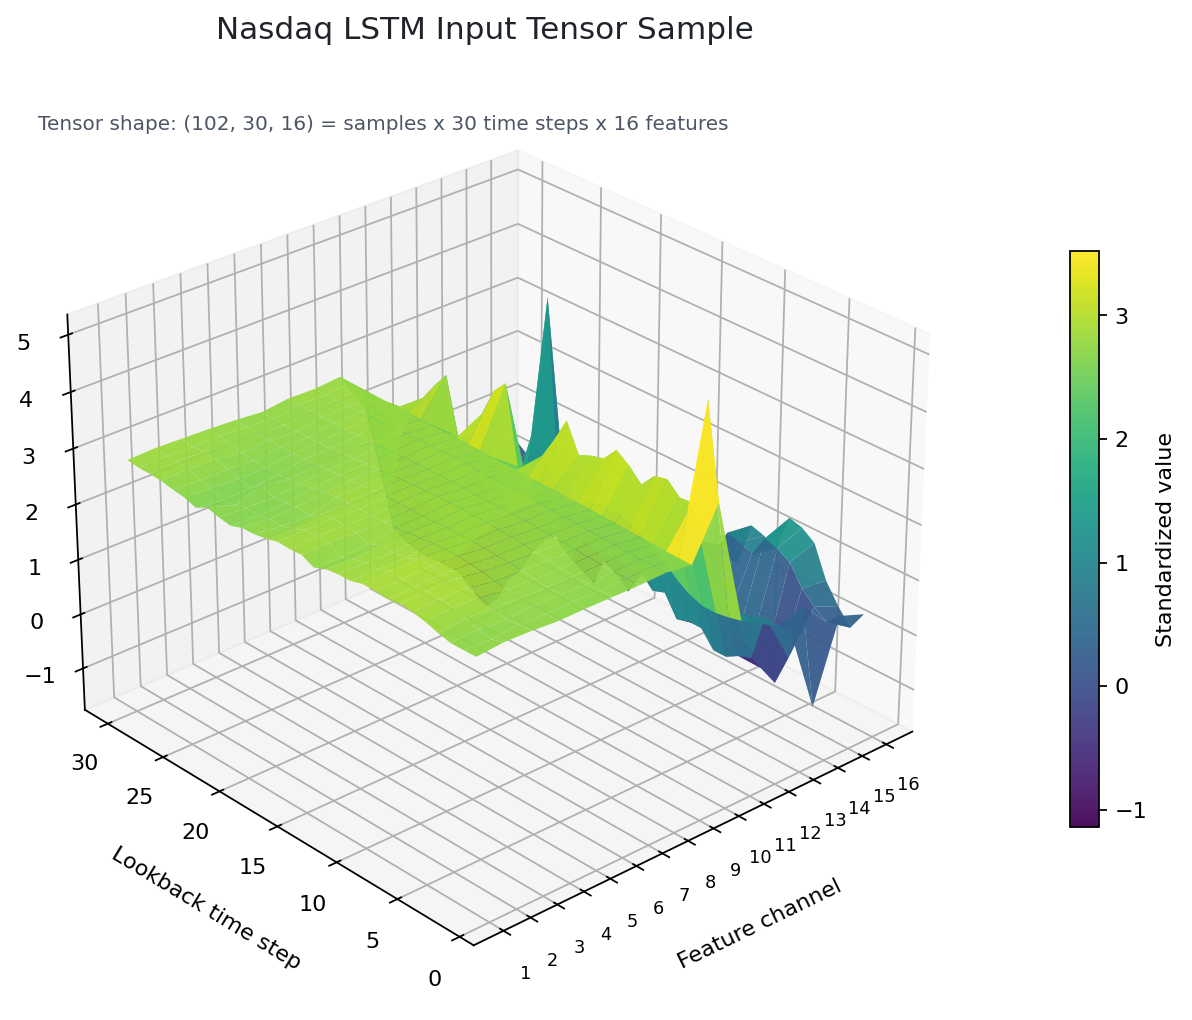

SP500


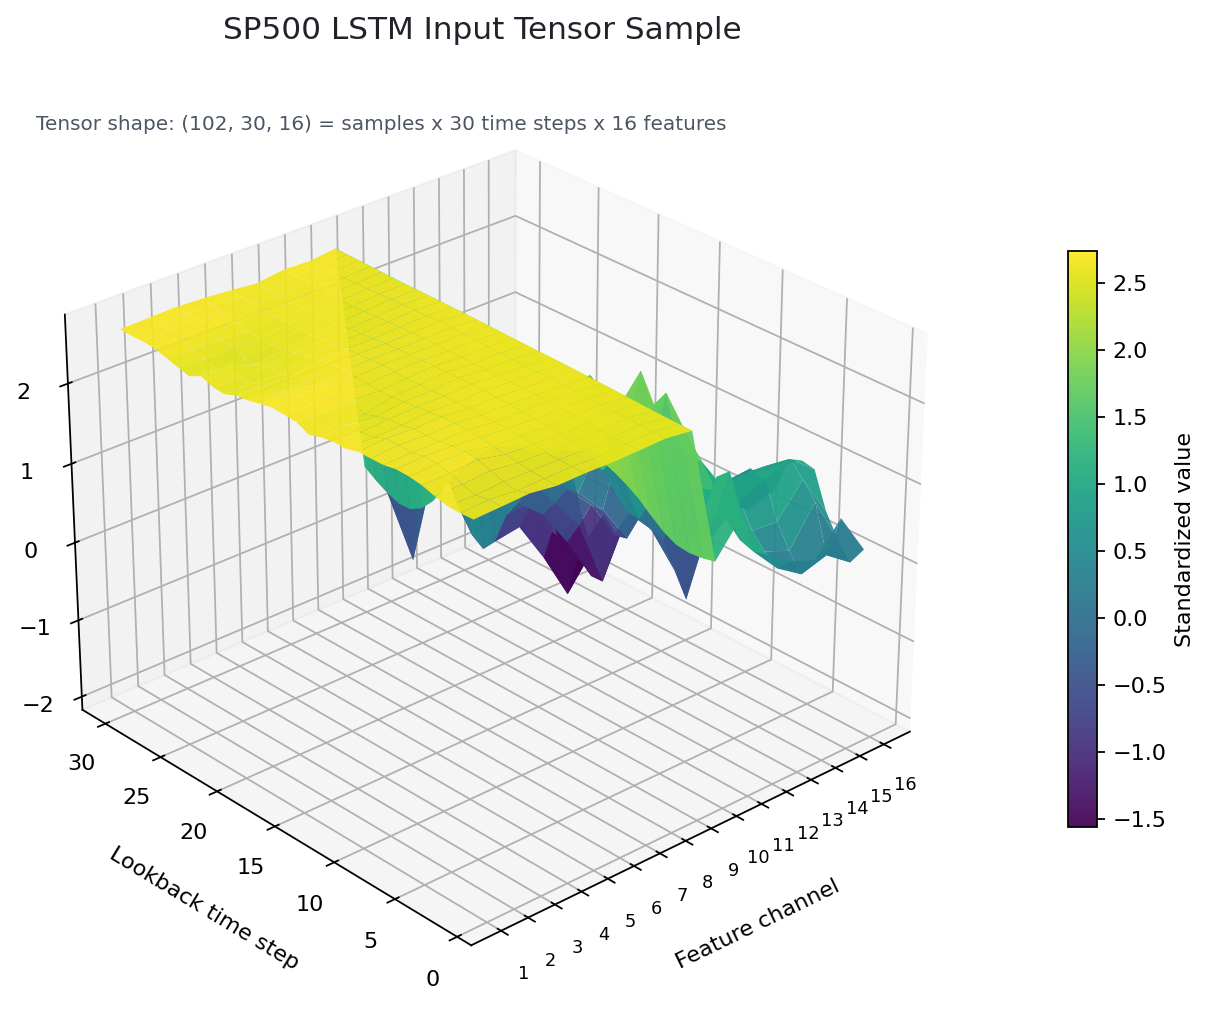

SOX


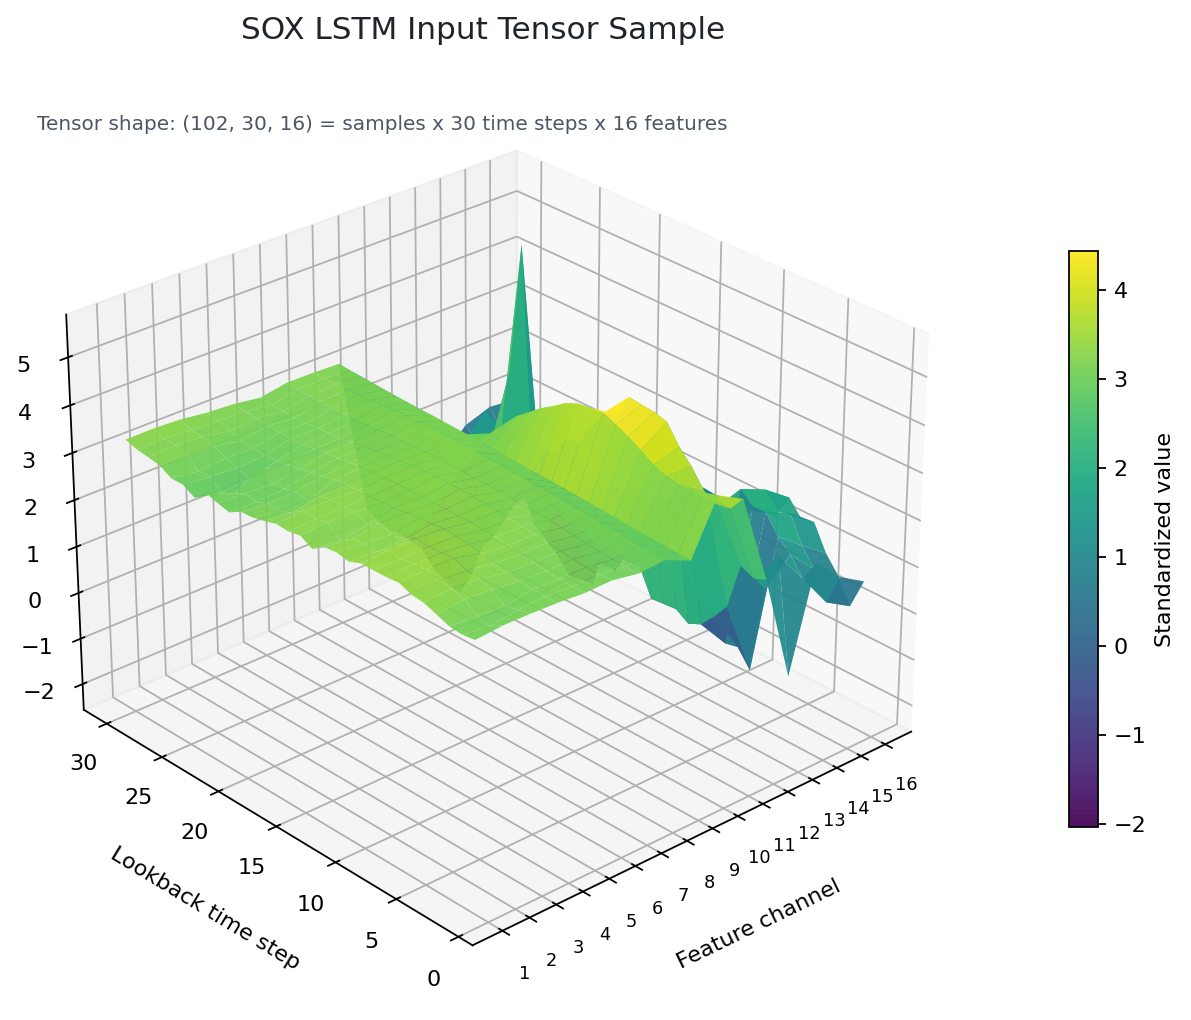

In [8]:
for index_name in summary["index"]:
    print(index_name)
    display(Image(filename=str(PLOTS_DIR / f"{index_name}_tensor_3d.png")))

## Daily Updated One-Month-Ahead Predicted Close vs Actual Index Close

Nasdaq


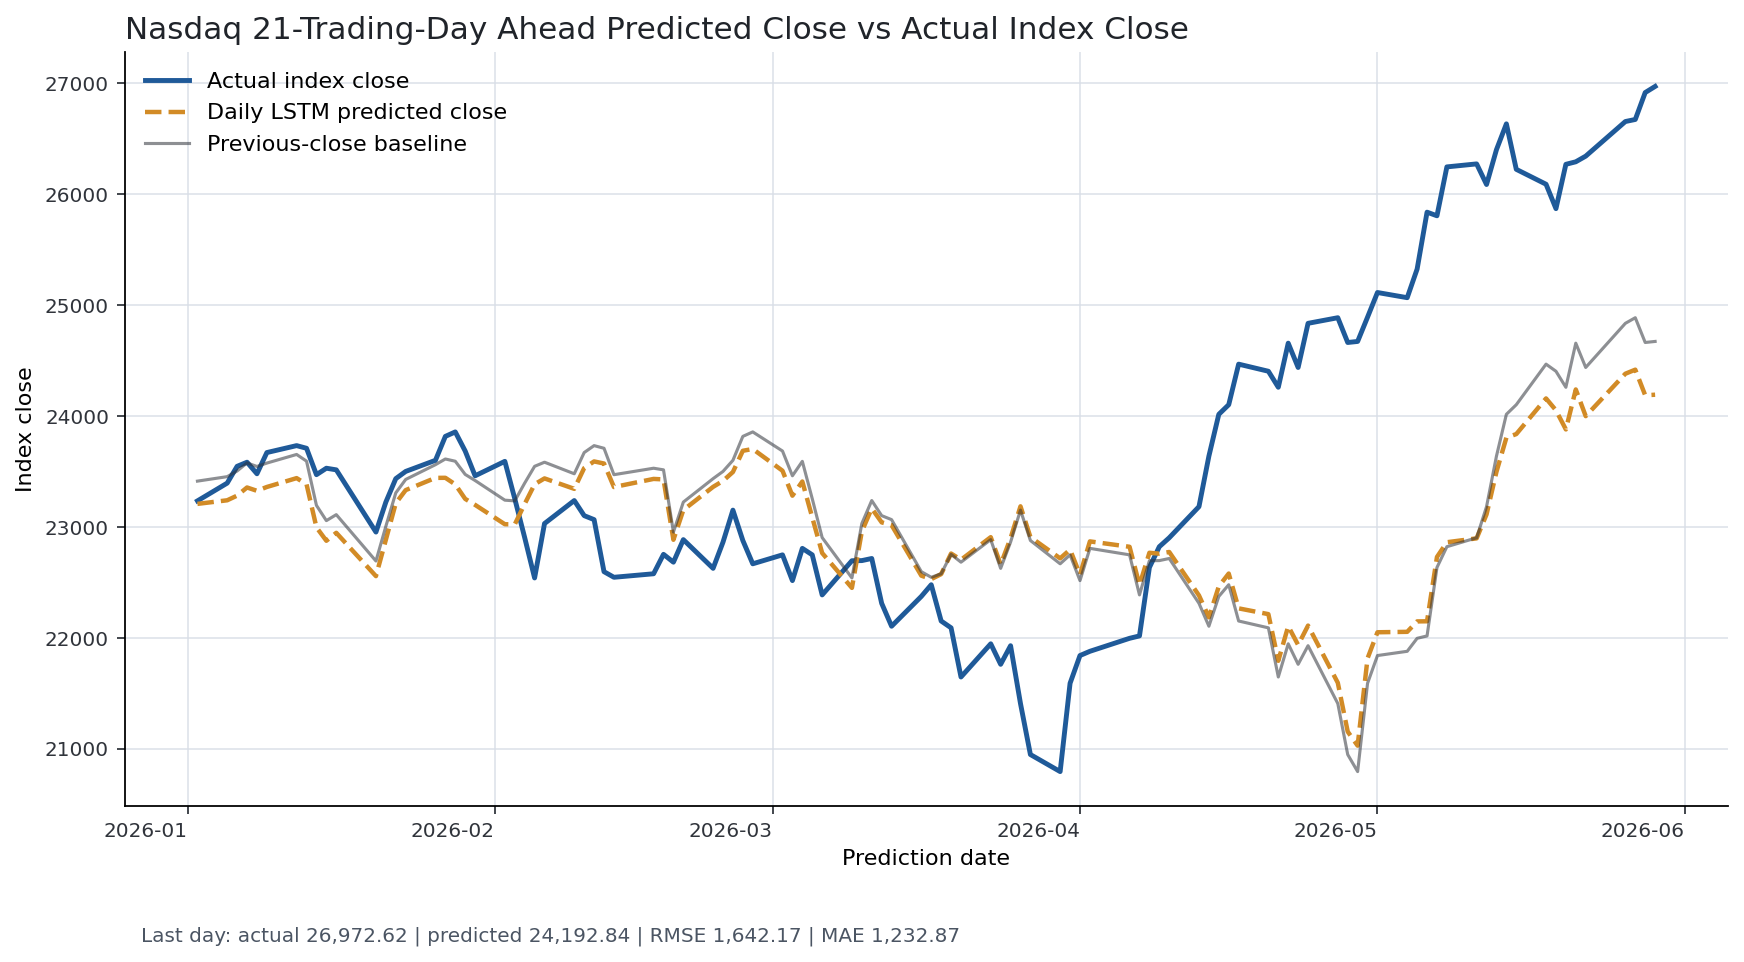

SP500


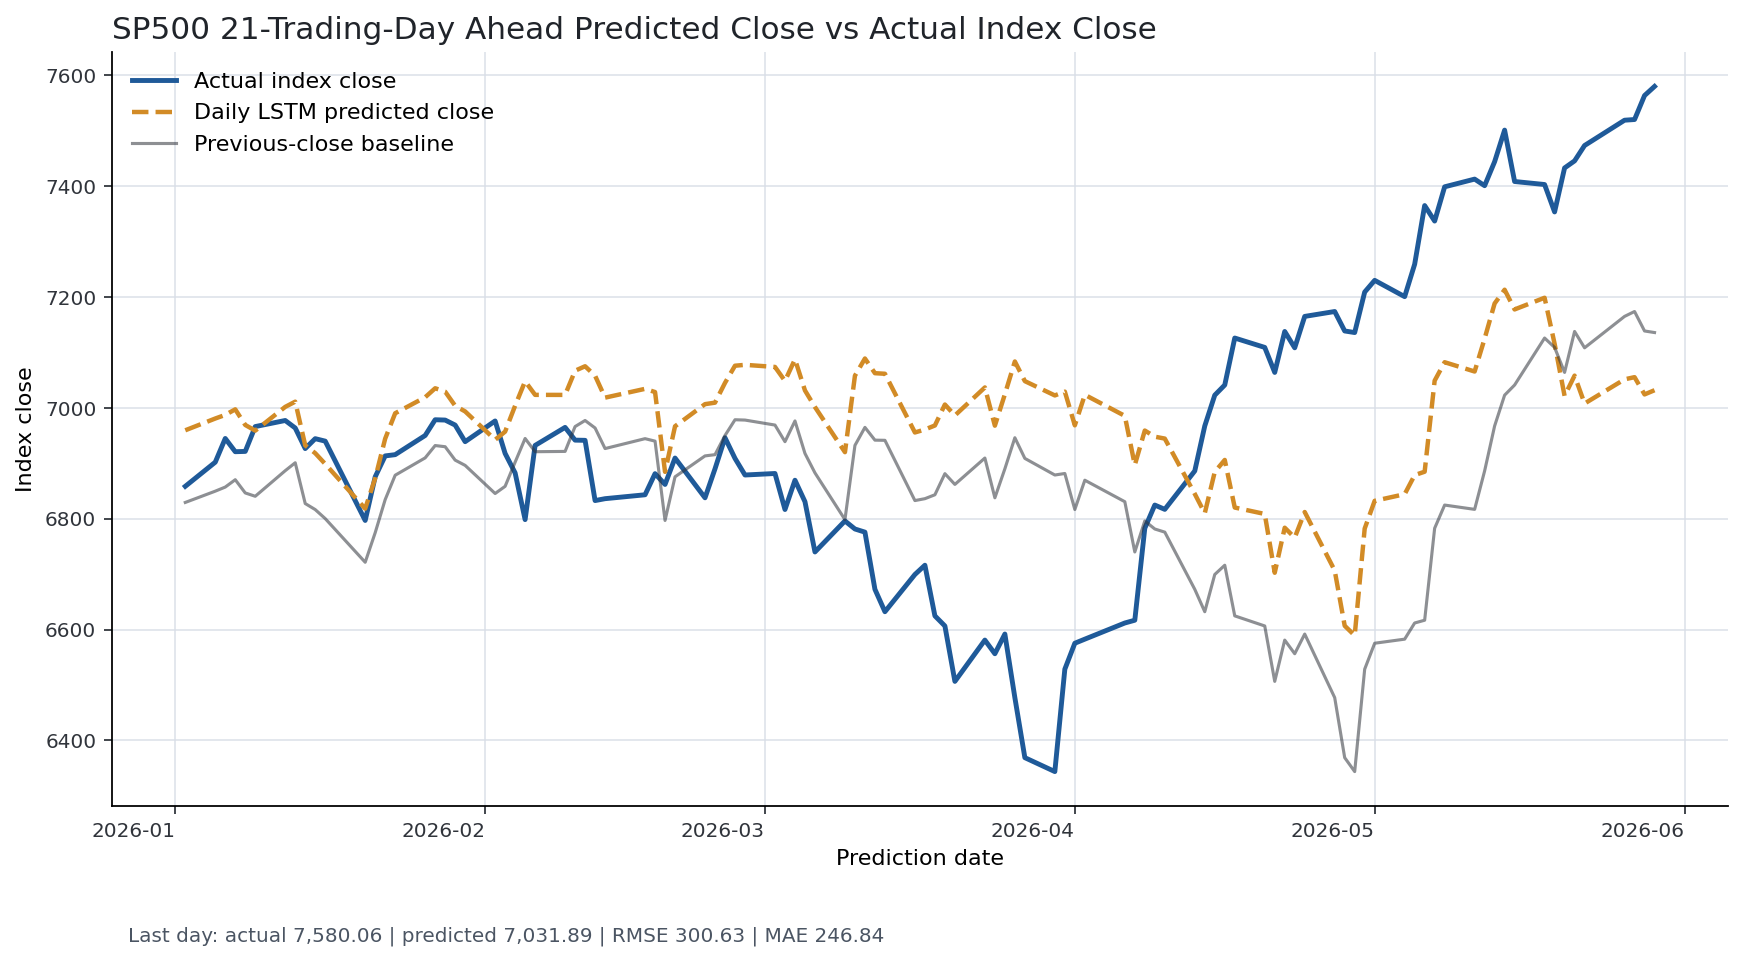

SOX


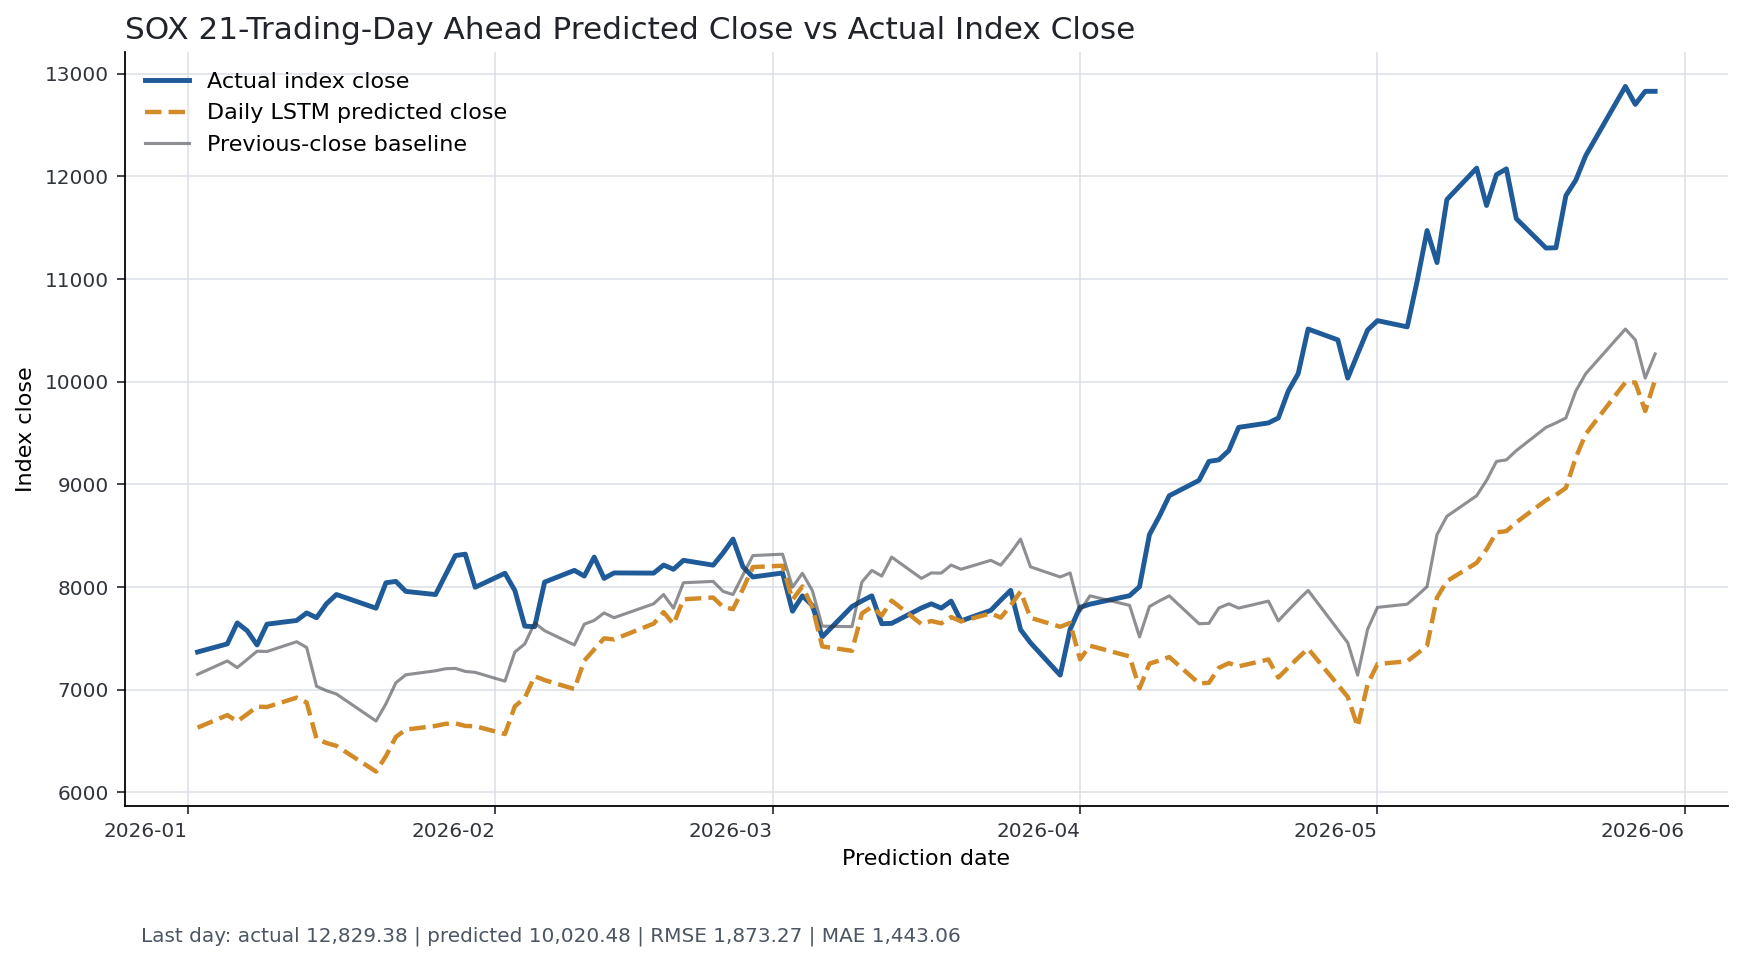

In [9]:
for index_name in summary["index"]:
    print(index_name)
    display(Image(filename=str(PLOTS_DIR / f"{index_name}_price_prediction.png")))